# climate-risk-stress-testing

**Author:** Sana Ur Rehman  
**Profession:** Data Scientist  
**Created:** 2026  

---

## License

This project is licensed under the **MIT License**. 

You are free to use, modify, distribute, and build upon this work for both commercial and non-commercial purposes, provided you give appropriate **credit** to the original author. For the full legal text and conditions, please refer to the `LICENSE` file included in this project's repository.

---

## Citation

If you reference or build upon this project, please provide appropriate credit.

For formal citation information, please see the project's `README.md` and `CITATION.cff` files.

[+] Project Root detected at: c:\Users\Yahya\Desktop\My folder\WQU\10. Capstone\Thesis Work\Risk Management & Sustainability (ESG)\Climate Risk Stress Testing


[*********************100%***********************]  5 of 5 completed


[!] Removed 1 rows containing negative/zero prices (likely Oil 2020 crash).
[+] Data Downloaded & Cleaned. Shape: (1257, 5)
[+] Processed data saved to: c:\Users\Yahya\Desktop\My folder\WQU\10. Capstone\Thesis Work\Risk Management & Sustainability (ESG)\Climate Risk Stress Testing\data\processed\market_returns.csv

--- Descriptive Statistics (Daily Log Returns) ---
Ticker          Oil        Green       Market        Brown
count   1256.000000  1256.000000  1256.000000  1256.000000
mean       0.000344     0.000543     0.000576     0.000488
std        0.038068     0.020321     0.013319     0.023207
min       -0.601676    -0.137093    -0.115886    -0.224910
25%       -0.013579    -0.009621    -0.004960    -0.010309
50%        0.002319     0.000000     0.000880     0.000800
75%        0.015504     0.011008     0.007219     0.012047
max        0.319634     0.107998     0.086731     0.148742
[+] Plot saved to: c:\Users\Yahya\Desktop\My folder\WQU\10. Capstone\Thesis Work\Risk Management & Su

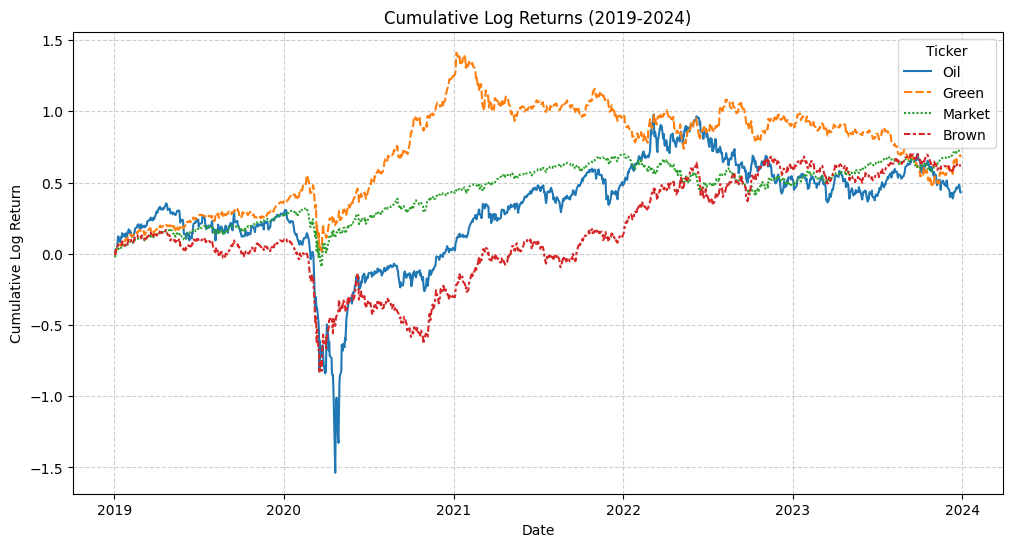

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import os

current_dir = os.getcwd()
if current_dir.endswith("notebooks"):
    
    PROJECT_ROOT = os.path.dirname(current_dir)
else:
    PROJECT_ROOT = current_dir

print(f"[+] Project Root detected at: {PROJECT_ROOT}")

PROCESSED_DATA_DIR = os.path.join(PROJECT_ROOT, "data", "processed")
FIGURES_DIR = os.path.join(PROJECT_ROOT, "outputs", "figures")

# --- Configuration ---
TICKERS = {
    'Brown': 'XLE',    # Energy Sector (High Transition Risk)
    'Green': 'ICLN',   # Clean Energy (Low Transition Risk)
    'Market': 'SPY',   # Market Benchmark
    'Oil': 'CL=F',     # Macro Factor
    'RiskFree': '^TNX' # 10-Year Treasury
}
START_DATE = '2019-01-01'
END_DATE = '2024-01-01'

def fetch_and_clean_data(tickers, start, end):
    print(f"Downloading data from {start} to {end}...")
    
    # auto_adjust=False to ensure we get 'Adj Close' or 'Close' raw
    raw_df = yf.download(list(tickers.values()), start=start, end=end, auto_adjust=False)
    
    # Robust Column Selection
    if 'Adj Close' in raw_df.columns.get_level_values(0):
        price_data = raw_df['Adj Close'].copy()
    elif 'Close' in raw_df.columns.get_level_values(0):
        price_data = raw_df['Close'].copy()
        print("[!] Using 'Close' prices.")
    else:
        raise KeyError("Could not find 'Adj Close' or 'Close' columns.")
    
    # Rename columns
    inv_tickers = {v: k for k, v in tickers.items()}
    price_data.rename(columns=inv_tickers, inplace=True)
    
    # Data Cleaning: Forward Fill first
    df_clean = price_data.ffill()
    
    # CRITICAL: Handle Negative Prices (Oil in 2020)
    # Log returns cannot be calculated on negative numbers. 
    # We drop days where ANY asset price was <= 0.
    rows_before = len(df_clean)
    df_clean = df_clean[df_clean > 0].dropna()
    rows_after = len(df_clean)
    
    if rows_before != rows_after:
        print(f"[!] Removed {rows_before - rows_after} rows containing negative/zero prices (likely Oil 2020 crash).")
        
    print(f"[+] Data Downloaded & Cleaned. Shape: {df_clean.shape}")
    return df_clean

def calculate_returns(prices_df):
    """
    Calculates Log Returns: r_t = ln(P_t / P_{t-1})
    """
    assets = [col for col in prices_df.columns if col != 'RiskFree']
    
    # Log Returns
    log_returns = np.log(prices_df[assets] / prices_df[assets].shift(1))
    
    # Drop the first NaN from shifting
    log_returns.dropna(inplace=True)
    
    return log_returns

# --- Execution ---
if __name__ == "__main__":
    # 1. Get Prices
    prices = fetch_and_clean_data(TICKERS, START_DATE, END_DATE)
    
    # 2. Get Returns
    returns = calculate_returns(prices)
    
    # 3. Save to Processed Data (Using the Robust Path)
    save_path = os.path.join(PROCESSED_DATA_DIR, "market_returns.csv")
    returns.to_csv(save_path)
    print(f"[+] Processed data saved to: {save_path}")

    # 4. Inspection
    print("\n--- Descriptive Statistics (Daily Log Returns) ---")
    print(returns.describe())

    # 5. Visualization
    plt.figure(figsize=(12, 6))
    cumulative_returns = np.cumsum(returns)
    sns.lineplot(data=cumulative_returns)
    plt.title("Cumulative Log Returns (2019-2024)")
    plt.ylabel("Cumulative Log Return")
    plt.xlabel("Date")
    plt.grid(True, linestyle='--', alpha=0.6)
    
    # Save Plot
    plot_path = os.path.join(FIGURES_DIR, "cumulative_returns_check.png")
    plt.savefig(plot_path)
    print(f"[+] Plot saved to: {plot_path}")
    plt.show()